In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import os
import zipfile
import kagglehub
from kagglehub import KaggleDatasetAdapter

print("TensorFlow version:", tf.__version__)
print("GPU Available:", "Yes" if tf.config.list_physical_devices('GPU') else "No")

TensorFlow version: 2.21.0
GPU Available: No


## 📥 Step 1: Upload the dataset

In [2]:
path = kagglehub.dataset_download("khoongweihao/covid19-xray-dataset-train-test-sets")
print("Path to dataset files:", path)
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Path to dataset files: C:\Users\eys20\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dataset-train-test-sets\versions\1
C:\Users\eys20\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dataset-train-test-sets\versions\1\xray_dataset_covid19\test\NORMAL\NORMAL2-IM-0035-0001.jpeg
C:\Users\eys20\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dataset-train-test-sets\versions\1\xray_dataset_covid19\test\NORMAL\NORMAL2-IM-0052-0001.jpeg
C:\Users\eys20\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dataset-train-test-sets\versions\1\xray_dataset_covid19\test\NORMAL\NORMAL2-IM-0058-0001.jpeg
C:\Users\eys20\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dataset-train-test-sets\versions\1\xray_dataset_covid19\test\NORMAL\NORMAL2-IM-0059-0001.jpeg
C:\Users\eys20\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dataset-train-test-sets\versions\1\xray_dataset_covid19\test\NORMAL\NORMAL2-IM-0072-0001.jpeg
C:\Users\eys20\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dat

## Step 2: Understanding the data structure (folder format)

In [3]:
# We need to understand the folder structure
def explore_folder(folder_path, level=0):
    indent = "  " * level
    items = os.listdir(folder_path)[:5]  # Take only the first 5 items
    for item in items:
        print(f"{indent}- {item}")
        item_path = os.path.join(folder_path, item)
        if os.path.isdir(item_path):
            explore_folder(item_path, level + 1)

# Assume the path is as follows (it may vary depending on your download)
data_path = path  # or the path you obtained after downloading
print("Folder structure:")
explore_folder(data_path)

Folder structure:
- xray_dataset_covid19
  - test
    - NORMAL
      - NORMAL2-IM-0035-0001.jpeg
      - NORMAL2-IM-0052-0001.jpeg
      - NORMAL2-IM-0058-0001.jpeg
      - NORMAL2-IM-0059-0001.jpeg
      - NORMAL2-IM-0072-0001.jpeg
    - PNEUMONIA
      - ryct.2020200034.fig2.jpeg
      - ryct.2020200034.fig5-day0.jpeg
      - ryct.2020200034.fig5-day4.jpeg
      - ryct.2020200034.fig5-day7.jpeg
      - SARS-10.1148rg.242035193-g04mr34g0-Fig8a-day0.jpeg
  - train
    - NORMAL
      - IM-0001-0001.jpeg
      - IM-0003-0001.jpeg
      - IM-0005-0001.jpeg
      - IM-0006-0001.jpeg
      - IM-0007-0001.jpeg
    - PNEUMONIA
      - 01E392EE-69F9-4E33-BFCE-E5C968654078.jpeg
      - 1-s2.0-S0140673620303706-fx1_lrg.jpg
      - 1-s2.0-S1684118220300608-main.pdf-001.jpg
      - 1-s2.0-S1684118220300608-main.pdf-002.jpg
      - 1-s2.0-S1684118220300682-main.pdf-002-a1.png


## Step 3: Data Preprocessing

In [4]:
# Define main parameters
IMG_HEIGHT = 224   # Image height (large enough for models)
IMG_WIDTH = 224    # Image width
BATCH_SIZE = 16    # Number of images per batch during training
SEED = 42          # Fixed seed for reproducibility

# Where is the data located? (adjust the path if needed)
TRAIN_PATH = os.path.join(path, 'xray_dataset_covid19', 'train')  # may need adjustment
TEST_PATH = os.path.join(path, 'xray_dataset_covid19', 'test')

# First: check if the path exists
print("Does the training folder exist?", os.path.exists(TRAIN_PATH))
print("Training folder contents:", os.listdir(TRAIN_PATH) if os.path.exists(TRAIN_PATH) else "Not found")

# Second: load data using ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training (helps the model generalize better)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values between 0 and 1
    rotation_range=20,        # Slight rotation
    width_shift_range=0.1,    # Shift left/right
    height_shift_range=0.1,   # Shift up/down
    horizontal_flip=True,     # Flip horizontally
    zoom_range=0.1,           # Slight zoom
    validation_split=0.2      # Use 20% for validation
)

# For testing (no augmentation, only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',  # binary classification (Normal / Pneumonia)
    subset='training',    # training data
    seed=SEED
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',  # validation data
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # important for evaluation
)

# Print dataset information
print("\n--- Dataset Summary ---")
print(f"Number of training images: {train_generator.samples}")
print(f"Number of validation images: {validation_generator.samples}")
print(f"Number of test images: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

Does the training folder exist? True
Training folder contents: ['NORMAL', 'PNEUMONIA']
Found 120 images belonging to 2 classes.
Found 28 images belonging to 2 classes.
Found 40 images belonging to 2 classes.

--- Dataset Summary ---
Number of training images: 120
Number of validation images: 28
Number of test images: 40
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


## Step 4: Previewing the images (making sure everything is correct)

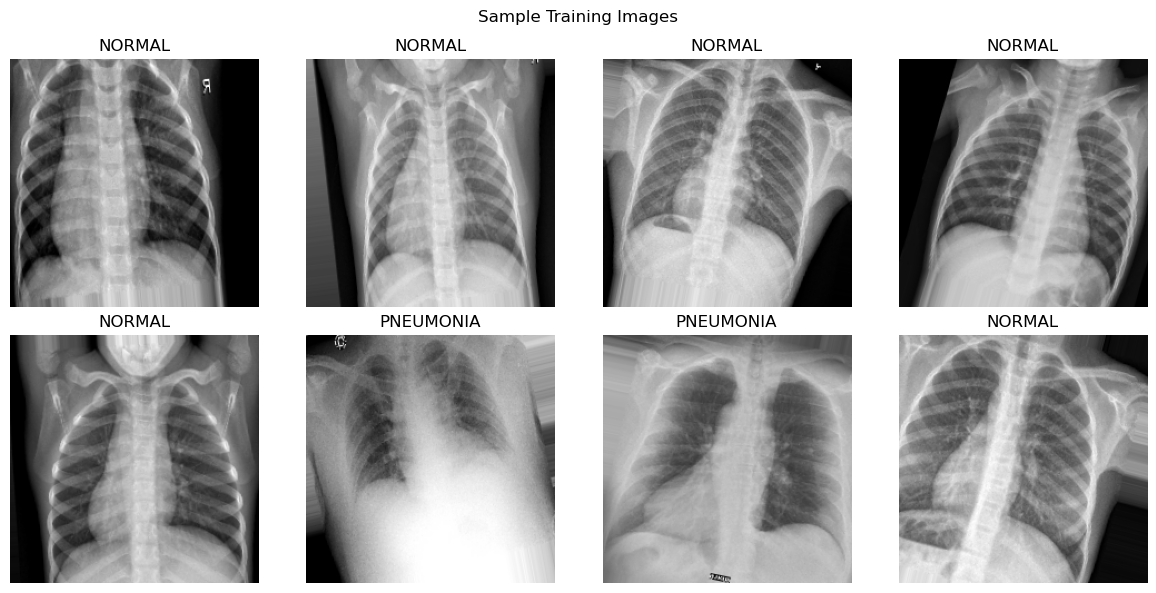

In [5]:
# Display some sample images from the training dataset
def show_sample_images(generator, title="Sample Images"):
    images, labels = next(generator)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    
    for i in range(8):
        axes[i].imshow(images[i])
        label = "PNEUMONIA" if labels[i] == 1 else "NORMAL"
        axes[i].set_title(f"{label}")
        axes[i].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample_images(train_generator, "Sample Training Images")

## Step 5: Building the VGG model (first model)

In [6]:
def build_vgg_model():
    # 1. Load the pre-trained model without the top (final) layers
    base_model = applications.VGG16(
        weights='imagenet',   # Pre-trained on ImageNet
        include_top=False,    # Exclude top layers (we will add our own)
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    
    # 2. Freeze the base model layers (do not update their weights)
    base_model.trainable = False
    
    # 3. Add custom layers for binary classification
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),  # Convert 3D feature maps to 1D
        layers.Dense(128, activation='relu'),  # Hidden layer
        layers.Dropout(0.5),  # Reduce overfitting
        layers.Dense(1, activation='sigmoid')  # Output layer (probability between 0 and 1)
    ])
    
    return model

# Build the model
vgg_model = build_vgg_model()

# Compile the model
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Print model summary
vgg_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 6: VGG Model Training

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 103s 12s/step - accuracy: 0.5167 - auc: 0.5115 - loss: 0.7688 - val_accuracy: 0.7857 - val_auc: 0.9949 - val_loss: 0.6158
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 75s 10s/step - accuracy: 0.6417 - auc: 0.7290 - loss: 0.6145 - val_accuracy: 0.8571 - val_auc: 0.9949 - val_loss: 0.5406
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 81s 9s/step - accuracy: 0.7000 - auc: 0.7672 - loss: 0.5972 - val_accuracy: 0.9643 - val_auc: 1.0000 - val_loss: 0.4506
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 74s 9s/step - accuracy: 0.7667 - auc: 0.8776 - loss: 0.5033 - val_accuracy: 0.9643 - val_auc: 1.0000 - val_loss: 0.3932
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 87s 11s/step - accuracy: 0.8500 - auc: 0.9125 - loss: 0.4499 - val_accuracy: 0.9643 - val_auc: 0.9949 - val_loss: 0.3625
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 88s 12s/step - accuracy: 0.8833 - auc: 0.9551 - loss: 0.3981 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.3301
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 88s 11s/step - accuracy

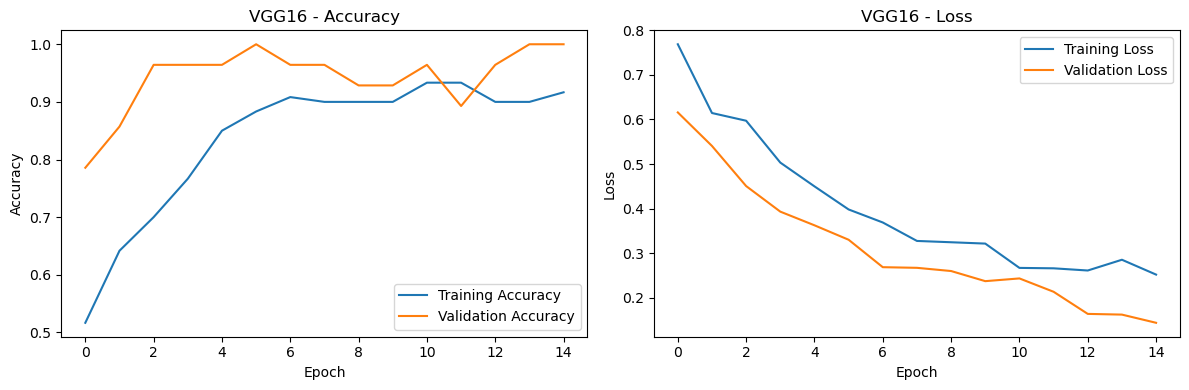

In [7]:
# Number of training epochs
EPOCHS = 15  # 15 epochs (each epoch = the model sees all images once)

# Train the model
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=1  # display training progress
)

# Plot training curves
def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{model_name} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{model_name} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_vgg, "VGG16")

## Step 7: Evaluate the VGG model

3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 7s/step

--- VGG16 - Evaluation Results ---
              precision    recall  f1-score   support

      NORMAL       1.00      0.90      0.95        20
   PNEUMONIA       0.91      1.00      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



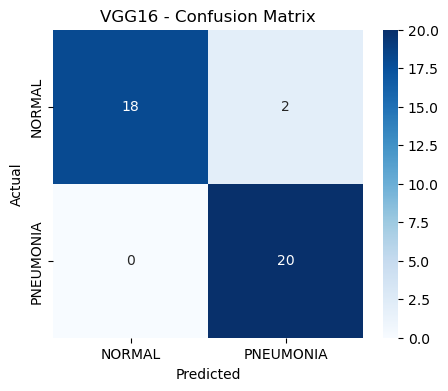

AUC Score: 0.9875


In [8]:
def evaluate_model(model, test_generator, model_name):
    # Make predictions on test data
    y_pred_prob = model.predict(test_generator)
    y_pred = (y_pred_prob > 0.5).astype(int)
    y_true = test_generator.classes
    # Calculate evaluation metrics
    print(f"\n--- {model_name} - Evaluation Results ---")
    print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    # Calculate AUC
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    print(f"AUC Score: {roc_auc:.4f}")
    
    return {
        'model_name': model_name,
        'auc': roc_auc,
        'confusion_matrix': cm
    }

results_vgg = evaluate_model(vgg_model, test_generator, "VGG16")

## 🔁 Step 8: Building and training GoogLeNet (InceptionV3)

Starting InceptionV3 training...
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.7417 - auc: 0.8096 - loss: 0.5829 - val_accuracy: 0.7143 - val_auc: 0.8112 - val_loss: 0.6356
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7750 - auc: 0.9008 - loss: 0.4079 - val_accuracy: 0.7143 - val_auc: 0.8393 - val_loss: 0.6307
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8000 - auc: 0.9260 - loss: 0.3513 - val_accuracy: 0.7500 - val_auc: 0.9719 - val_loss: 0.5098
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8417 - auc: 0.9390 - loss: 0.3174 - val_accuracy: 0.7857 - val_auc: 0.9031 - val_loss: 0.3867
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8833 - auc: 0.9553 - loss: 0.2696 - val_accuracy: 0.8929 - val_auc: 0.9005 - val_loss: 0.4254
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.9167 - auc: 0.9508 - loss: 0.2849 - val_accuracy: 0.8929 - val_auc: 0.9745 - val_loss: 0.2512
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━

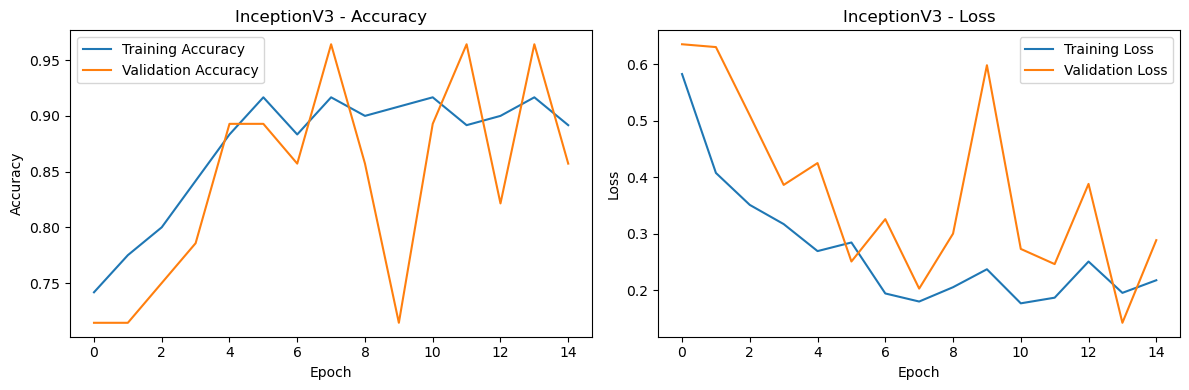

3/3 ━━━━━━━━━━━━━━━━━━━━ 46s 13s/step

--- InceptionV3 - Evaluation Results ---
              precision    recall  f1-score   support

      NORMAL       0.95      1.00      0.98        20
   PNEUMONIA       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



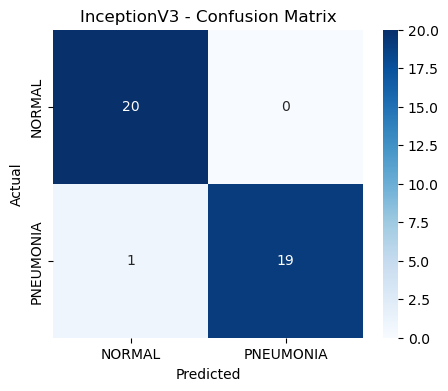

AUC Score: 0.9925


In [9]:
def build_inception_model():
    # InceptionV3 usually expects input size 299×299,
    # but we use 224×224 with a slight adjustment
    base_model = applications.InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Add custom classification layers
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Build and train InceptionV3 model
inception_model = build_inception_model()
# Compile the model
inception_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("Starting InceptionV3 training...")

history_inception = inception_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=1
)

# Plot training curves
plot_training_history(history_inception, "InceptionV3")
# Evaluate the model
results_inception = evaluate_model(inception_model, test_generator, "InceptionV3")

## Step 9: Building and Training ResNet

training start ResNet50...
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 115s 9s/step - accuracy: 0.5333 - auc: 0.4982 - loss: 0.8197 - val_accuracy: 0.5000 - val_auc: 0.9082 - val_loss: 0.7488
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 53s 6s/step - accuracy: 0.4500 - auc: 0.4975 - loss: 0.7584 - val_accuracy: 0.5000 - val_auc: 0.9337 - val_loss: 0.6905
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 54s 7s/step - accuracy: 0.5250 - auc: 0.5839 - loss: 0.6901 - val_accuracy: 0.5000 - val_auc: 0.8980 - val_loss: 0.6747
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step - accuracy: 0.4917 - auc: 0.5179 - loss: 0.7384 - val_accuracy: 0.5000 - val_auc: 0.9541 - val_loss: 0.6675
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step - accuracy: 0.5833 - auc: 0.5376 - loss: 0.7274 - val_accuracy: 0.7143 - val_auc: 0.9362 - val_loss: 0.6608
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step - accuracy: 0.5500 - auc: 0.5382 - loss: 0.7065 - val_accuracy: 0.5357 - val_auc: 0.9464 - val_loss: 0.6665
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 

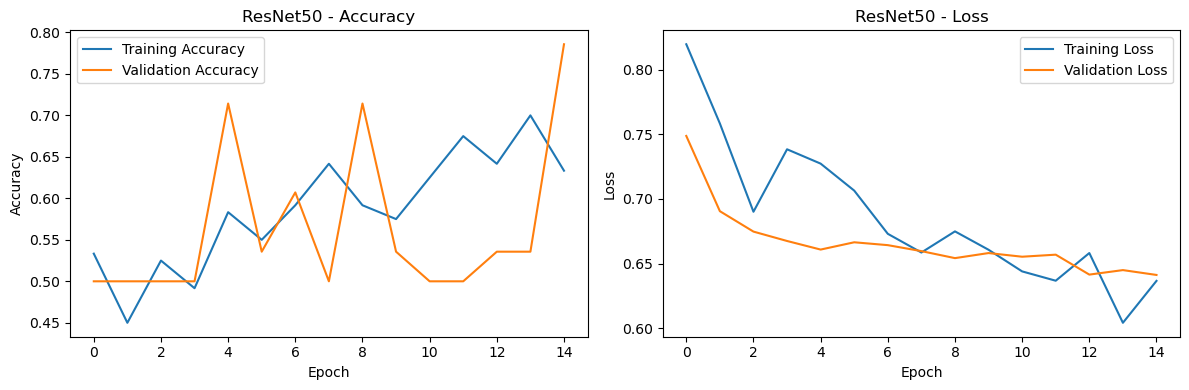

2/3 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step  WARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000185D6AB2CA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 9s/step

--- ResNet50 - Evaluation Results ---
              precision    recall  f1-score   support

      NORMAL       0.91      1.00      0.95        20
   PNEUMONIA       1.00      0.90      0.95        2

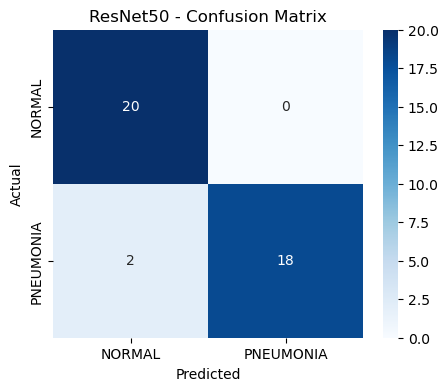

AUC Score: 1.0000


In [10]:
def build_resnet_model():
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

resnet_model = build_resnet_model()
resnet_model.compile(optimizer='adam', loss='binary_crossentropy',
                     metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("training start ResNet50...")
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=1
)

plot_training_history(history_resnet, "ResNet50")
results_resnet = evaluate_model(resnet_model, test_generator, "ResNet50")

## 📈 Step 10: Final comparison between the three models

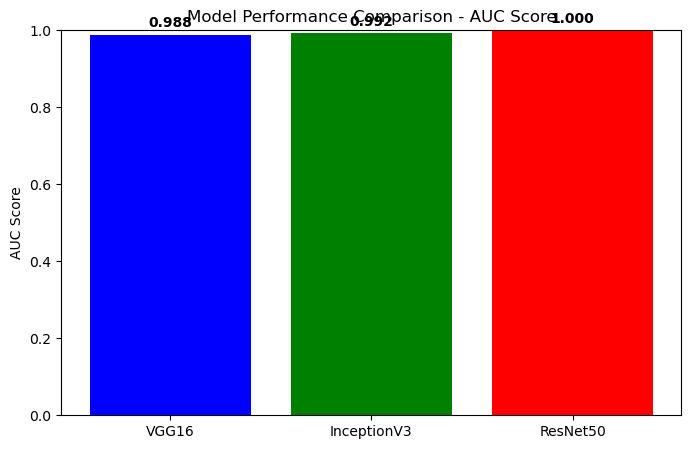

In [18]:
# Collect all results
all_results = [results_vgg, results_inception, results_resnet]
model_names = [r['model_name'] for r in all_results]
auc_scores = [r['auc'] for r in all_results]

# Plot AUC comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, auc_scores, color=['blue', 'green', 'red'])
plt.ylim(0, 1)
plt.ylabel('AUC Score')
plt.title('Model Performance Comparison - AUC Score')

for bar, score in zip(bars, auc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{score:.3f}',
        ha='center',
        fontweight='bold'
    )

plt.show()

In [14]:
# Save the trained InceptionV3 model
inception_model.save("inceptionv3_pneumonia_model.h5")
print("Model saved successfully!")

Model saved successfully!
